In [1]:
import sys, os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
sys.path.insert(0, '..')

import numpy  as np
import tensorflow as tf
import math
import pandas as pd

from model.data import getDataETTh1,Normalize
from model.model import myInformer
from model.exp import Exp

import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so


In [10]:
# EXP
d_model = 512
HEADS = 8
RATE = 0.05
SEQ_LEN = 96
FACTOR = 5
BATCH_SIZE = 32
GLOBAL_SIZE = 3200
d_ff= 2048
N=2
PRED_LEN =24
FEATURES= 7
TIME_FEATURES = 4
EPOCHS = 10
settings = {'batch_size':BATCH_SIZE, 'seq_len':SEQ_LEN, 'global_size':GLOBAL_SIZE, 'd_model':d_model, 'd_ff':d_ff,
            'e_layer':N, 'd_layer':1, 'rate':RATE, 'factor':FACTOR, 'heads':HEADS, 'pred_len':PRED_LEN, 'features':FEATURES, 'timeFeatures':TIME_FEATURES }
# print(settings)
# Creation du model Exp
myExpFct = Exp(settings)
myExpFct.build()
myExpFct._buildModel(0.01)
model = myExpFct.train(EPOCHS)
# # Formatage des données
# dX, dy = list(myExpFct.dataset)[59]
# X = dX[:,:,0:7]
# declen = SEQ_LEN//2
# X_dec = X[:,0:declen,:]
# Xdate = dX[:,:,7:]
# Xdate_dec = Xdate[:,0:declen,:]
# y = dy[:]
# print(dy.shape)
# X_dec_padd = tf.zeros(shape=(BATCH_SIZE,PRED_LEN,X.shape[-1]))
# X_date_dec_padd = tf.zeros(shape=(BATCH_SIZE,PRED_LEN,Xdate.shape[-1]))
# X_dec = tf.concat([X_dec,X_dec_padd],1)
# Xdate_dec = tf.concat([Xdate_dec,X_date_dec_padd],1)

# pred = myExpFct.pred(X,X_dec,Xdate, Xdate_dec, training=False)
# # pred = myExpFct._pred()

# B,L,F = pred.shape
# pred = myExpFct.scaler.inverse_transform(tf.reshape(pred,shape=(B*L,F)))
# pred = tf.cast(tf.reshape(pred, shape=(B,L,F)), tf.float32)
# x_padd = tf.zeros(shape=(BATCH_SIZE,24,7))
# pred = tf.concat([x_padd,pred],1)

# x_ = myExpFct.x_enc

# B,L,F = x_.shape
# x_ = tf.reshape(x_, shape=(B*L,F))
# x_ = myExpFct.scaler.inverse_transform(x_)
# x_ = tf.reshape(x_, shape=(B,L,F))

# v_min = tf.reduce_min(x_)
# v_max = tf.reduce_max(x_)

# fig = plt.figure(figsize=(18,2))
# plt.plot(range(pred[0,0:SEQ_LEN-PRED_LEN,6].shape[0], SEQ_LEN),pred[0,SEQ_LEN-PRED_LEN:SEQ_LEN,6], 'r--', label="Predicted");
# plt.plot(range(x_[0,0:SEQ_LEN-PRED_LEN,6].shape[0]),x_[0,0:SEQ_LEN-PRED_LEN,6], label="Training");
# plt.plot(range(SEQ_LEN-PRED_LEN, SEQ_LEN),x_[0,SEQ_LEN-PRED_LEN:SEQ_LEN,6], 'g:', label="Réel ?");
# plt.legend();

# fig = plt.figure(figsize=(18,2))
# # ax = fig.subplots(221)
# for i in range(0,BATCH_SIZE,32):
#     sns.heatmap(x_[i,:,:], vmin=v_min, vmax=v_max, cmap=sns.color_palette("hls", 256)).set_title('encoder x');# for i in range(0,BATCH_SIZE,8):

# df_raw = myExpFct.dataFct.df_Data
# fig = plt.figure(figsize=(18,2))
# sns.lineplot(x=df_raw['date'][0:1000],y=df_raw['OT'][0:1000]).set_title('Torch EMbedding');
# # plt.plot( data=df_raw[['date','OT']][0:1000], label='Torch EMbedding');


BUILD
data_ (3200, 11)
ici (35200, 1)
(3104, 96, 11)
Epoch: 0 -> loss=69.18/0.00 -> Accuracy=-21.11%/0.00% - [91.43s]
Epoch: 1 -> loss=1.70/0.00 -> Accuracy=22.32%/0.00% - [89.81s]
Epoch: 2 -> loss=1.38/0.00 -> Accuracy=38.20%/0.00% - [90.39s]
Epoch: 3 -> loss=1.13/0.00 -> Accuracy=47.02%/0.00% - [90.10s]
Epoch: 4 -> loss=0.97/0.00 -> Accuracy=52.87%/0.00% - [87.72s]
Epoch: 5 -> loss=0.81/0.00 -> Accuracy=57.30%/0.00% - [88.44s]
Epoch: 6 -> loss=0.71/0.00 -> Accuracy=60.78%/0.00% - [87.09s]
Epoch: 7 -> loss=0.63/0.00 -> Accuracy=63.54%/0.00% - [84.85s]
Epoch: 8 -> loss=0.62/0.00 -> Accuracy=65.73%/0.00% - [87.80s]
Epoch: 9 -> loss=0.61/0.00 -> Accuracy=67.48%/0.00% - [88.95s]
Total time taken: 886.6s


ValueError: x and y must have same first dimension, but have shapes (10,) and (0,)

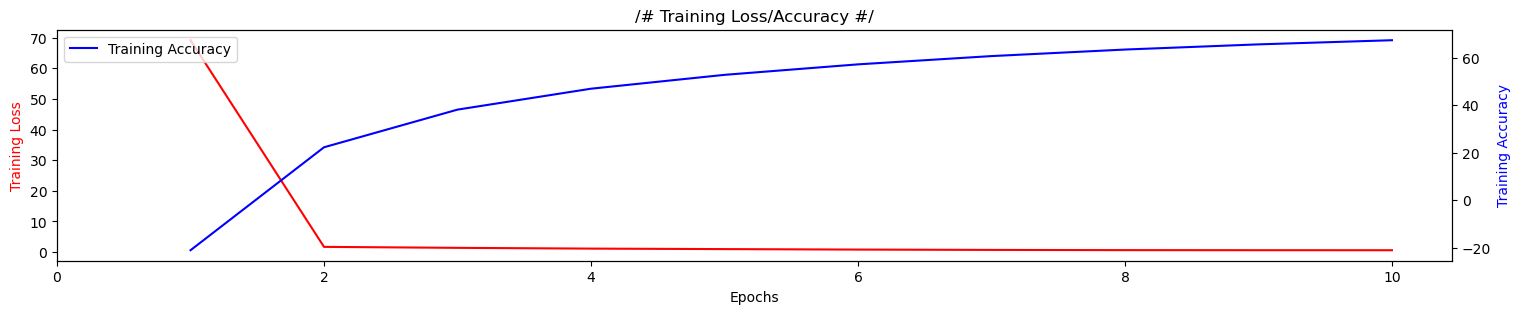

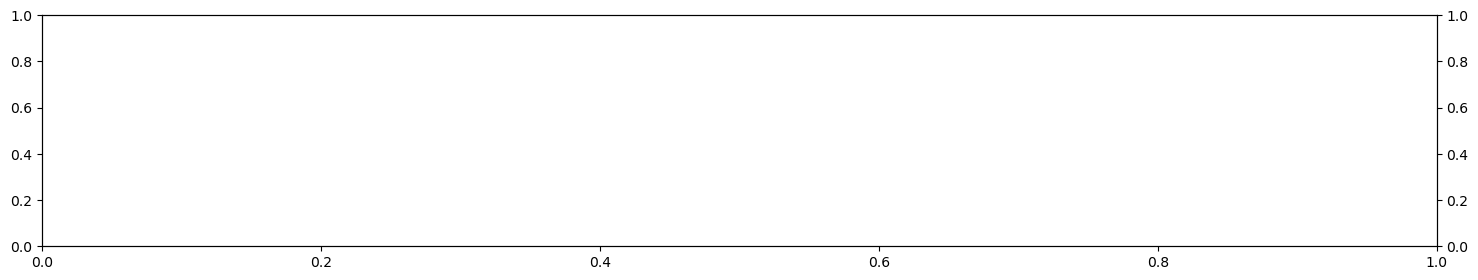

In [11]:
# Visualisation des Courbes d'appretissage

from pickle import load
 
# Load the training and validation loss dictionaries
train_loss = load(open('train_loss.pkl', 'rb'))
train_accuracy = load(open('train_accuracy.pkl', 'rb'))
val_loss = load(open('val_loss.pkl', 'rb'))
val_accuracy = load(open('val_accuracy.pkl', 'rb'))
 
# Retrieve each dictionary's values
train_values = train_loss.values()
train_acc_values = train_accuracy.values()
val_values = val_loss.values()
val_acc_values = val_accuracy.values()
 
# Generate a sequence of integers to represent the epoch numbers
g_epochs = range(1, EPOCHS+1)

fig, ax1 = plt.subplots(figsize=(18,3))
ax2 = ax1.twinx()
# Plot and label the training and validation loss values
ax1.plot(g_epochs, train_values, label='Training Loss', color='red')
# ax2.plot(g_epochs, train_values, label='Training Loss', color='blue')
ax2.plot(g_epochs, train_acc_values, label='Training Accuracy', color='blue')
 
# Add in a title and axes labels
plt.title('/# Training Loss/Accuracy #/')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Training Loss',color='red')
ax2.set_ylabel('Training Accuracy',color='blue')
# Set the tick locations
plt.xticks(np.arange(0, EPOCHS+1, 2))
# Display the plot
plt.legend(loc='best');
# plt.show()
#----------------------------
fig, ax1 = plt.subplots(figsize=(18,3))
ax2 = ax1.twinx()
# Plot and label the training and validation loss values
ax1.plot(g_epochs, val_values, label='Validation Loss', color='red')
ax2.plot(g_epochs, val_acc_values, label='Validation Accuracy', color='blue')
# Add in a title and axes labels
plt.title('/# Validation Loss/Accuracy #/')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Validation Loss',color='red')
ax2.set_ylabel('Validation Accuracy',color='blue')
# Set the tick locations
plt.xticks(np.arange(0, EPOCHS+1, 2))
# Display the plot
plt.legend(loc='best');
# plt.show()

In [ ]:
myExpFct.X.shape


(32, 96, 11)
X (96, 7)
Xdate (96, 4)
(1, 48, 4)
(1, 24, 4)
(1, 96, 7)
(1, 96, 4)
(1, 72, 7)
(1, 72, 4)
tf.Tensor(
[0.16888937 0.1688894  0.1688894  0.1688894  0.1688894  0.1688894
 0.1688894  0.16888943 0.1688894  0.16888942 0.1688894  0.1688894
 0.1688894  0.16888943 0.1688894  0.1688894  0.1688894  0.1688894
 0.1688894  0.1688894  0.1688894  0.16888942 0.1688894  0.1688894 ], shape=(24,), dtype=float32)
(1, 24, 7)


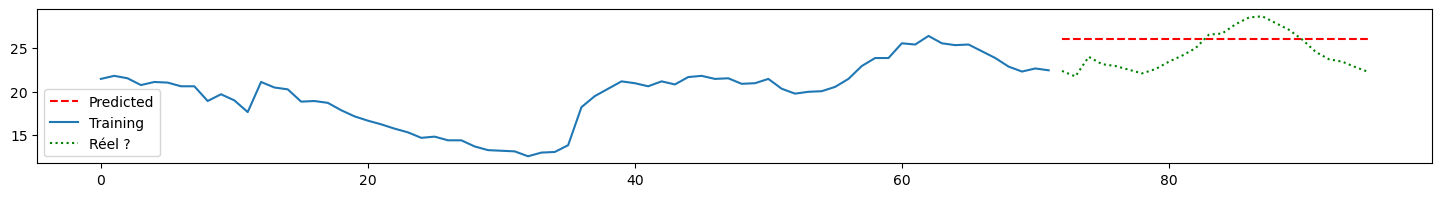

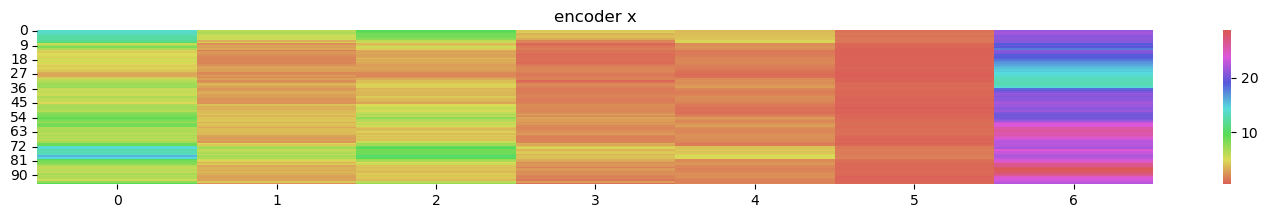

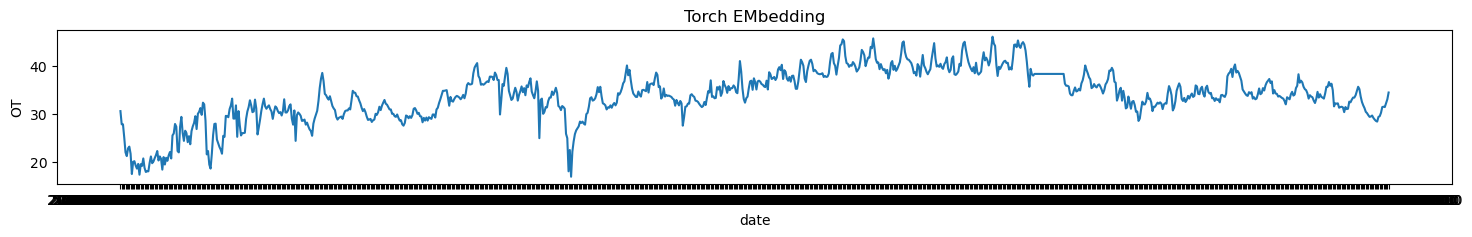

In [13]:
# EXP
# model.batch_size=1
# Formatage des données
dX, dy = list(myExpFct.dataset)[5]
print(dX.shape)
X = dX[0,:,0:7]
print('X',X.shape)
declen = SEQ_LEN//2
X_dec = X[:declen,:]
Xdate = dX[0,:,7:]
print('Xdate',Xdate.shape)
Xdate_dec = dX[0,0:declen,7:]
X = tf.reshape(X, shape=(1,SEQ_LEN,7))
Xdate = tf.reshape(Xdate,shape=(1,SEQ_LEN,4))
X_dec = tf.reshape(X_dec, shape=(1,declen,7))
Xdate_dec = tf.reshape(Xdate_dec, shape=(1,declen,4))
X_dec_padd = tf.zeros(shape=(1,PRED_LEN,X.shape[-1]))
X_date_dec_padd = tf.zeros(shape=(1,PRED_LEN,Xdate.shape[-1]))
X_dec = tf.concat([X_dec,X_dec_padd],1)
print(Xdate_dec.shape)
print(X_date_dec_padd.shape)
Xdate_dec = tf.concat([Xdate_dec,X_date_dec_padd],1)

print(X.shape)
print(Xdate.shape)
print(X_dec.shape)
print(Xdate_dec.shape)
# pred = myExpFct.pred(X,X_dec, Xdate, Xdate_dec, training=False)[0]
pred = model(X,Xdate,X_dec, Xdate_dec, training=False)[0]
pred = tf.reshape(pred,shape=(1,PRED_LEN,7))
print(pred[0,:,6])
print(pred.shape)
B,L,F = pred.shape
pred = myExpFct.scaler.inverse_transform(tf.reshape(pred,shape=(B*L,F)))
pred = tf.cast(tf.reshape(pred, shape=(B,L,F)), tf.float32)
x_padd = tf.zeros(shape=(1,72,7))
pred = tf.concat([x_padd,pred],1)

x_ = myExpFct.x_enc

B,L,F = x_.shape
x_ = tf.reshape(x_, shape=(B*L,F))
x_ = myExpFct.scaler.inverse_transform(x_)
x_ = tf.reshape(x_, shape=(B,L,F))

v_min = tf.reduce_min(x_)
v_max = tf.reduce_max(x_)

fig = plt.figure(figsize=(18,2))
plt.plot(range(pred[0,0:SEQ_LEN-PRED_LEN,6].shape[0], SEQ_LEN),pred[0,SEQ_LEN-PRED_LEN:SEQ_LEN,6], 'r--', label="Predicted");
plt.plot(range(x_[0,0:SEQ_LEN-PRED_LEN,6].shape[0]),x_[0,0:SEQ_LEN-PRED_LEN,6], label="Training");
plt.plot(range(SEQ_LEN-PRED_LEN, SEQ_LEN),x_[0,SEQ_LEN-PRED_LEN:SEQ_LEN,6], 'g:', label="Réel ?");
plt.legend();

fig = plt.figure(figsize=(18,2))
# ax = fig.subplots(221)
for i in range(0,BATCH_SIZE,32):
    sns.heatmap(x_[i,:,:], vmin=v_min, vmax=v_max, cmap=sns.color_palette("hls", 256)).set_title('encoder x');# for i in range(0,BATCH_SIZE,8):

df_raw = myExpFct.dataFct.df_Data
fig = plt.figure(figsize=(18,2))
sns.lineplot(x=df_raw['date'][0:1000],y=df_raw['OT'][0:1000]).set_title('Torch EMbedding');
# plt.plot( data=df_raw[['date','OT']][0:1000], label='Torch EMbedding');


In [5]:
print(myExpFct.dataFct.data[0:3,:])
print(myExpFct.dataFct.df_Data.iloc[0:5])
print(myExpFct.dataFct.df_Data.shape)

[[-0.6680851  -0.82659055 -0.84361183 -0.89081474 -0.73550597 -0.8543643
   0.35750909 -0.61938765 -0.8684795  -0.90999481 -0.74393358]
 [-0.67364816 -0.82380903 -0.84805397 -0.89230929 -0.73803839 -0.85307732
   0.2435911  -0.61938765 -0.8684795  -0.8684795  -0.74393358]
 [-0.69590036 -0.83771666 -0.85689673 -0.89525688 -0.75319149 -0.85942916
   0.2435911  -0.61938765 -0.8684795  -0.82696419 -0.74393358]]
                  date   HUFL   HULL   MUFL   MULL   LUFL   LULL         OT  \
0  2016-07-01 00:00:00  5.827  2.009  1.599  0.462  4.203  1.340  30.531000   
1  2016-07-01 01:00:00  5.693  2.076  1.492  0.426  4.142  1.371  27.787001   
2  2016-07-01 02:00:00  5.157  1.741  1.279  0.355  3.777  1.218  27.787001   
3  2016-07-01 03:00:00  5.090  1.942  1.279  0.391  3.807  1.279  25.044001   
4  2016-07-01 04:00:00  5.358  1.942  1.492  0.462  3.868  1.279  21.948000   

   mois  jour  heure  sJour  
0     7     1      0      4  
1     7     1      1      4  
2     7     1      2    

In [6]:
print(tf.reduce_max(myExpFct.X).numpy())
print(myExpFct.dataFct.dataN.shape)
print(tf.reduce_min(myExpFct.dataFct.dataN).numpy())
print(tf.reduce_max(myExpFct.dataFct.dataN).numpy())
print(tf.reduce_mean(myExpFct.dataFct.dataN).numpy())
print(myExpFct.dataFct.df_Data.describe())
print(myExpFct.dataFct.scalerData)
print((myExpFct.X.shape))
print(tf.reduce_max(myExpFct.X[:,:,6]))

1.0
(35200, 1)
-1.0
1.0
-0.5657069646502865
               HUFL          HULL          MUFL          MULL          LUFL  \
count  17420.000000  17420.000000  17420.000000  17420.000000  17420.000000   
mean       7.375141      2.242242      4.300239      0.881568      3.066062   
std        7.067744      2.042342      6.826978      1.809293      1.164506   
min      -22.705999     -4.756000    -25.087999     -5.934000     -1.188000   
25%        5.827000      0.737000      3.296000     -0.284000      2.315000   
50%        8.774000      2.210000      5.970000      0.959000      2.833000   
75%       11.788000      3.684000      8.635000      2.203000      3.625000   
max       23.643999     10.114000     17.341000      7.747000      8.498000   

               LULL            OT          mois          jour         heure  \
count  17420.000000  17420.000000  17420.000000  17420.000000  17420.000000   
mean       0.856932     13.324672      6.529047     15.647761     11.497704   
std    

In [ ]:
print(11*17420)